In [7]:
from pathlib import Path
import sys
import subprocess

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

DATA_PATH = ROOT / "single-cell-tracks_exp1-6_noErbB2.csv.gz"
META_PATH = ROOT / "01-readme-experiment-description_2022-04-05.csv"
SCRIPT_PATH = ROOT / "scripts" / "compare_spatiotemporal_behavior_copy.py"
OUTPUT_ROOT = ROOT / "analysis_outputs_A1"

OUTPUT_ROOT.mkdir(exist_ok=True)

print("ROOT:", ROOT)
print("DATA exists:", DATA_PATH.exists())
print("META exists:", META_PATH.exists())
print("SCRIPT exists:", SCRIPT_PATH.exists())
print("OUTPUT_ROOT:", OUTPUT_ROOT)

ROOT: c:\Users\olcia\Downloads\spatiotemporal-starter
DATA exists: True
META exists: True
SCRIPT exists: True
OUTPUT_ROOT: c:\Users\olcia\Downloads\spatiotemporal-starter\analysis_outputs_A1


In [11]:
cmd = [
    sys.executable,
    str(SCRIPT_PATH),
    "--data-path", str(DATA_PATH),
    "--meta-path", str(META_PATH),
    "--signal-col", "ERKKTR_ratio",
    "--group-by", "mutation",
    "--spatial-radius", "60",
    "--future-window-frames", "3",
    "--jump-quantile", "0.9",
    "--include-mutations",
    "WT",
    "AKT1_E17K",
    "PIK3CA_E545K",
    "PIK3CA_H1047R",
    "PTEN_del",
    "--output-dir", str(OUTPUT_ROOT),
]

print("Running:")
print(" ".join(cmd))

result = subprocess.run(cmd, capture_output=True, text=True)

print("RETURN CODE:", result.returncode)
print("\nSTDOUT:")
print(result.stdout)
print("\nSTDERR:")
print(result.stderr)

if result.returncode != 0:
    raise RuntimeError("A1 script failed. Check STDERR above.")

Running:
c:\Users\olcia\AppData\Local\Programs\Python\Python312\python.exe c:\Users\olcia\Downloads\spatiotemporal-starter\scripts\compare_spatiotemporal_behavior_copy.py --data-path c:\Users\olcia\Downloads\spatiotemporal-starter\single-cell-tracks_exp1-6_noErbB2.csv.gz --meta-path c:\Users\olcia\Downloads\spatiotemporal-starter\01-readme-experiment-description_2022-04-05.csv --signal-col ERKKTR_ratio --group-by mutation --spatial-radius 60 --future-window-frames 3 --jump-quantile 0.9 --include-mutations WT AKT1_E17K PIK3CA_E545K PIK3CA_H1047R PTEN_del --output-dir c:\Users\olcia\Downloads\spatiotemporal-starter\analysis_outputs_A1
RETURN CODE: 0

STDOUT:

A1 mutation comparison
Mutations included: ['AKT1_E17K', 'PIK3CA_E545K', 'PIK3CA_H1047R', 'PTEN_del', 'WT']
Sites included: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]
Number of blocks: 120

Comparison task complete.
Grouping variable: Mutation
Blocks analysed: 120
Output directory: c:\Use

In [12]:
#wczytanie wyników
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

A1_DIR = ROOT / "analysis_outputs_A1" / "comparison_mutation_ERKKTR_ratio"
OUTPUT_DIR = ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

group = pd.read_csv(A1_DIR / "group_level_summary.csv")
block = pd.read_csv(A1_DIR / "block_level_summary.csv")

display(group)
display(block.head())

print("group columns:", group.columns.tolist())
print("block columns:", block.columns.tolist())

,comparison_group,n_blocks,n_unique_sites,n_unique_experiments,total_nodes,mean_relative_risk,median_relative_risk,mean_risk_difference,mean_exposed_jump_rate,mean_unexposed_jump_rate,mean_spatial_edges,mean_temporal_edges
0,PIK3CA_H1047R,24,4,6,4661580,3.200310,3.214033,0.141754,0.207863,0.066110,6.968846e+05,192749.625000
1,WT,24,4,6,7874257,1.742349,1.737245,0.054427,0.127974,0.073547,2.079152e+06,326484.583333
2,PIK3CA_E545K,24,4,6,8443205,1.707110,1.688656,0.059877,0.145206,0.085329,2.385621e+06,349580.125000
3,AKT1_E17K,21,4,6,8797999,1.581421,1.453965,0.053217,0.152170,0.098953,3.450509e+06,417039.285714
4,PTEN_del,27,8,6,5764607,1.556633,1.555826,0.045523,0.127909,0.082386,9.433794e+05,212421.111111


,exp_id,site_id,mutation,signal_col,spatial_radius,future_window_frames,jump_threshold,n_nodes,n_spatial_edges,n_temporal_edges,...,n_frames,n_exposed_nodes,n_unexposed_nodes,future_jump_rate_if_neighbor_jumps_now,future_jump_rate_if_no_neighbor_jumps_now,risk_difference,relative_risk,Conditions,group_site_id,comparison_group
0,1,1,WT,ERKKTR_ratio,60.0,3,0.036543,356632,2389504,354834,...,258,146620,210012,0.131455,0.074867,0.056588,1.755850,GF_deprived_48h_before_aquisition_FN_(0.25ug/c...,1,WT
1,1,2,WT,ERKKTR_ratio,60.0,3,0.033298,341603,2188412,340009,...,258,133686,207917,0.124665,0.070485,0.054180,1.768681,GF_deprived_48h_before_aquisition_FN_(0.25ug/c...,2,WT
2,1,3,WT,ERKKTR_ratio,60.0,3,0.035837,356470,2385276,354785,...,258,146010,210460,0.118889,0.073011,0.045878,1.628362,GF_deprived_48h_before_aquisition_FN_(0.25ug/c...,3,WT
3,1,4,WT,ERKKTR_ratio,60.0,3,0.038620,378022,2702454,376126,...,258,161340,216682,0.129614,0.068907,0.060707,1.880994,GF_deprived_48h_before_aquisition_FN_(0.25ug/c...,4,WT
4,1,5,AKT1_E17K,ERKKTR_ratio,60.0,3,0.022628,448311,3863383,446302,...,258,224573,223738,0.155272,0.096390,0.058883,1.610885,GF_deprived_48h_before_aquisition_FN_(0.25ug/c...,5,AKT1_E17K


group columns: ['comparison_group', 'n_blocks', 'n_unique_sites', 'n_unique_experiments', 'total_nodes', 'mean_relative_risk', 'median_relative_risk', 'mean_risk_difference', 'mean_exposed_jump_rate', 'mean_unexposed_jump_rate', 'mean_spatial_edges', 'mean_temporal_edges']
block columns: ['exp_id', 'site_id', 'mutation', 'signal_col', 'spatial_radius', 'future_window_frames', 'jump_threshold', 'n_nodes', 'n_spatial_edges', 'n_temporal_edges', 'n_tracks', 'n_frames', 'n_exposed_nodes', 'n_unexposed_nodes', 'future_jump_rate_if_neighbor_jumps_now', 'future_jump_rate_if_no_neighbor_jumps_now', 'risk_difference', 'relative_risk', 'Conditions', 'group_site_id', 'comparison_group']


In [13]:
#średnie RR i St
wanted = ["WT", "AKT1_E17K", "PIK3CA_E545K", "PIK3CA_H1047R", "PTEN_del"]

rr_stats = (
    block[block["comparison_group"].isin(wanted)]
    .groupby("comparison_group")["relative_risk"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

rr_stats["std_error"] = rr_stats["std"] / np.sqrt(rr_stats["count"])

rr_stats = rr_stats.rename(columns={
    "comparison_group": "mutation",
    "mean": "mean_RR"
})

rr_stats

,mutation,mean_RR,std,count,std_error
0,AKT1_E17K,1.581421,0.329635,21,0.071932
1,PIK3CA_E545K,1.707110,0.156202,24,0.031885
2,PIK3CA_H1047R,3.200310,0.640017,24,0.130643
3,PTEN_del,1.556633,0.112361,27,0.021624
4,WT,1.742349,0.084226,24,0.017193


In [14]:
wt_values = block.loc[block["comparison_group"] == "WT", "relative_risk"].dropna()

test_rows = []

for mut in ["AKT1_E17K", "PIK3CA_E545K", "PIK3CA_H1047R", "PTEN_del"]:
    mut_values = block.loc[block["comparison_group"] == mut, "relative_risk"].dropna()
    
    stat, p = mannwhitneyu(wt_values, mut_values, alternative="two-sided")
    p_corr = min(p * 4, 1.0)
    
    test_rows.append({
        "mutation": mut,
        "p_value_vs_WT": p_corr,
        "significant": p_corr < 0.05
    })

stats_table = pd.DataFrame(test_rows)
stats_table

,mutation,p_value_vs_WT,significant
0,AKT1_E17K,1.384587e-02,True
1,PIK3CA_E545K,7.341158e-01,False
2,PIK3CA_H1047R,1.225466e-08,True
3,PTEN_del,1.464234e-06,True


In [15]:
final_table = rr_stats[["mutation", "mean_RR", "std_error"]].merge(
    stats_table,
    on="mutation",
    how="left"
)

final_table.loc[final_table["mutation"] == "WT", "p_value_vs_WT"] = np.nan
final_table.loc[final_table["mutation"] == "WT", "significant"] = False

order = ["WT", "AKT1_E17K", "PIK3CA_E545K", "PIK3CA_H1047R", "PTEN_del"]
final_table["mutation"] = pd.Categorical(final_table["mutation"], categories=order, ordered=True)
final_table = final_table.sort_values("mutation")

final_table.to_csv(OUTPUT_DIR / "mutations_comparison_table.csv", index=False)

final_table

,mutation,mean_RR,std_error,p_value_vs_WT,significant
4,WT,1.742349,0.017193,NaN,False
0,AKT1_E17K,1.581421,0.071932,1.384587e-02,True
1,PIK3CA_E545K,1.707110,0.031885,7.341158e-01,False
2,PIK3CA_H1047R,3.200310,0.130643,1.225466e-08,True
3,PTEN_del,1.556633,0.021624,1.464234e-06,True


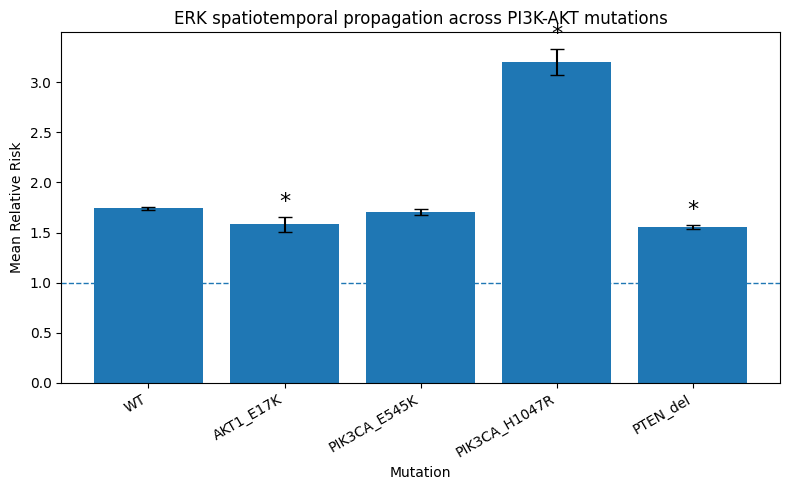

In [16]:
plot_data = final_table.copy()

plt.figure(figsize=(8, 5))
plt.bar(
    plot_data["mutation"].astype(str),
    plot_data["mean_RR"],
    yerr=plot_data["std_error"],
    capsize=5
)

plt.axhline(1, linestyle="--", linewidth=1)
plt.ylabel("Mean Relative Risk")
plt.xlabel("Mutation")
plt.title("ERK spatiotemporal propagation across PI3K-AKT mutations")
plt.xticks(rotation=30, ha="right")

for i, row in plot_data.reset_index(drop=True).iterrows():
    if bool(row["significant"]):
        plt.text(
            i,
            row["mean_RR"] + row["std_error"] + 0.05,
            "*",
            ha="center",
            va="bottom",
            fontsize=16
        )

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "mutations_barplot.png", dpi=300)
plt.show()

In [17]:
print((OUTPUT_DIR / "mutations_comparison_table.csv").exists())
print((OUTPUT_DIR / "mutations_barplot.png").exists())

True
True


In [10]:
print("SCRIPT_PATH:", SCRIPT_PATH)
print("SCRIPT exists:", SCRIPT_PATH.exists())

with open(SCRIPT_PATH, "r", encoding="utf-8") as f:
    txt = f.read()

print("--include-mutations" in txt)
print("A1 mutation comparison" in txt)
print("if __name__ == '__main__':" in txt or 'if __name__ == "__main__":' in txt)

SCRIPT_PATH: c:\Users\olcia\Downloads\spatiotemporal-starter\scripts\compare_spatiotemporal_behavior_copy.py
SCRIPT exists: True
True
True
True
